<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Autoencoder_Algorithm_on_Fashion_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Reshape,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA

In [5]:
print("Tensorflow Version:",tf.__version__)

Tensorflow Version: 2.20.0


In [6]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
print("Training Shape",X_train.shape)
print("Testing Shape",X_test.shape)

Training Shape (60000, 28, 28)
Testing Shape (10000, 28, 28)


In [8]:
fashion_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

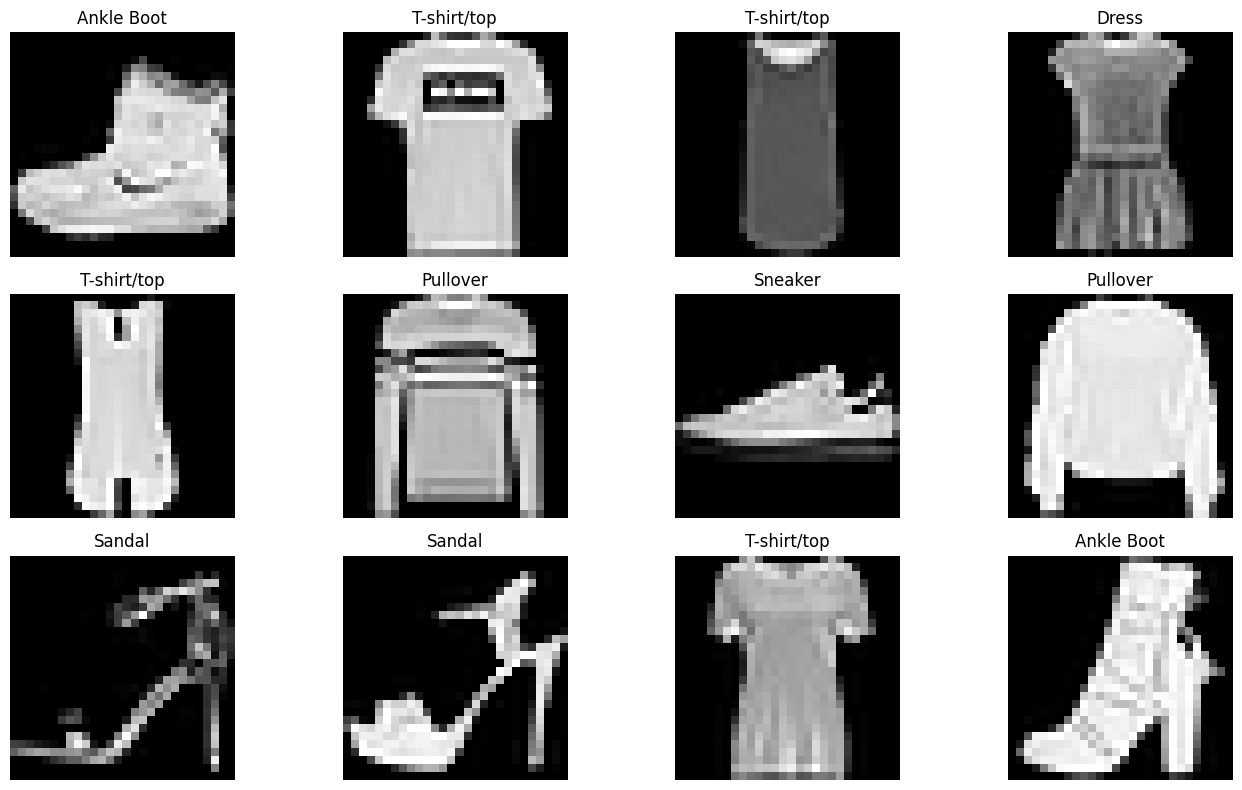

In [9]:
plt.figure(figsize=(14,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(X_train[i],cmap='gray')
  plt.title(fashion_labels[y_train[i]])
  plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
print("Minimum Pixel Value",X_train.min())
print("Maximum Pixel Value",X_train.max())

Minimum Pixel Value 0
Maximum Pixel Value 255


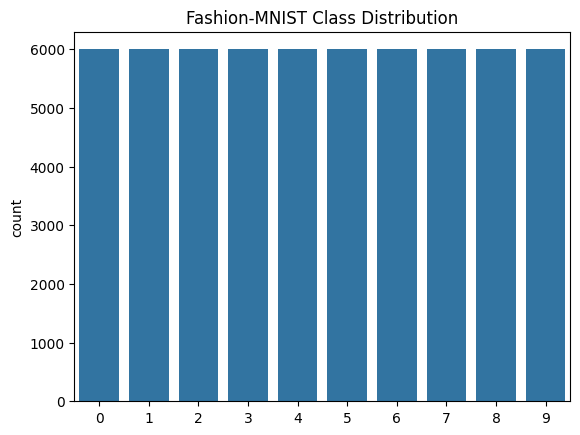

In [11]:
sns.countplot(x=y_train)
plt.title('Fashion-MNIST Class Distribution')
plt.show()

In [12]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [13]:
X_train_flat = X_train.reshape(-1,784)
X_test_flat = X_test.reshape(-1,784)

In [14]:
print(X_train_flat.shape)

(60000, 784)


In [15]:
input_dim = 784
input_layer = Input(shape=(input_dim,))

In [16]:
encoder = Dense(256, activation='relu')(input_layer)
encoder = Dense(128, activation='relu')(encoder)
encoder = Dense(64, activation='relu')(encoder)

latent_space = Dense(32, activation='relu')(encoder)

In [17]:
decoder = Dense(64, activation='relu')(latent_space)
decoder = Dense(128, activation='relu')(decoder)
decoder = Dense(256, activation='relu')(decoder)

output_layer = Dense(784, activation='sigmoid')(decoder)

In [18]:
autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [19]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,136 (1.87 MB)

 Trainable params: 489,136 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
autoencoder.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [21]:
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_flat,X_test_flat)
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.0063 - loss: 0.3754 - val_accuracy: 0.0131 - val_loss: 0.3215
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.0139 - loss: 0.3085 - val_accuracy: 0.0152 - val_loss: 0.3047
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.0169 - loss: 0.2994 - val_accuracy: 0.0128 - val_loss: 0.2987
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0156 - loss: 0.2951 - val_accuracy: 0.0110 - val_loss: 0.2976
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.0161 - loss: 0.2922 - val_accuracy: 0.0119 - val_loss: 0.2945
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0167 - loss: 0.2898 - val_accuracy: 0.0143 - val_loss: 0.2908
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.0171 - loss: 0.2878 - val_accuracy: 0.0162 - val_loss: 0.2891
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.0183 - loss: 0.2862 - val_

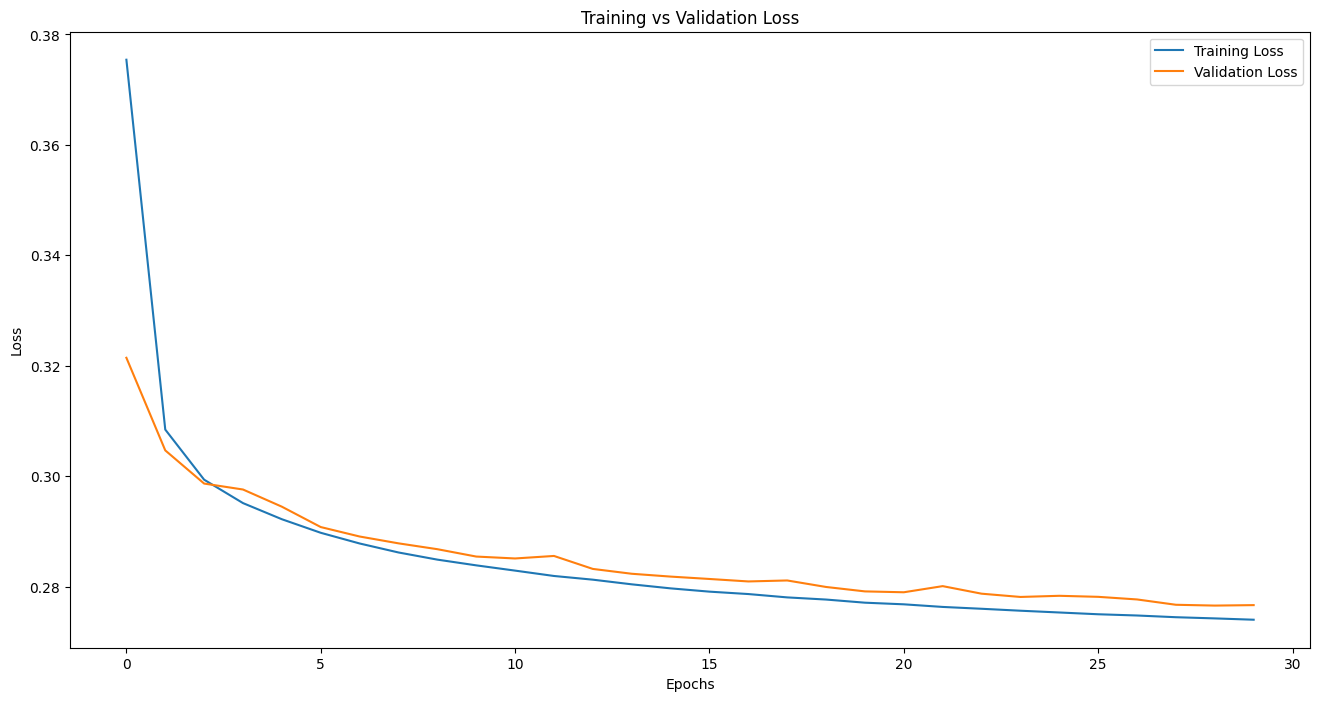

In [23]:
plt.figure(figsize=(16,8))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [24]:
reconstructed = autoencoder.predict(X_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
reconstructed = reconstructed.reshape(-1,28,28)

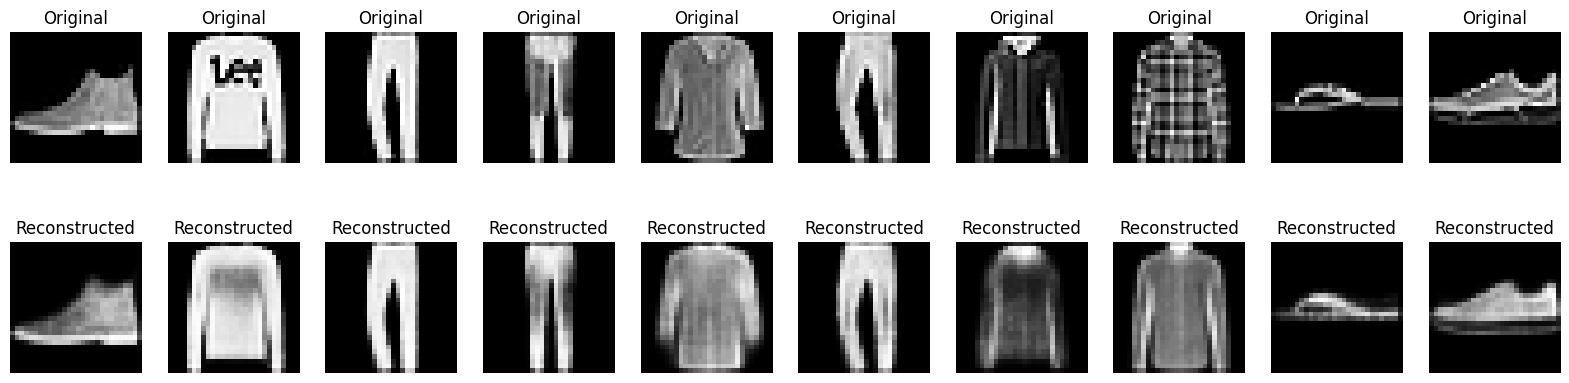

In [26]:
n = 10

plt.figure(figsize=(20,5))

for i in range(n):

    # Original
    ax = plt.subplot(2,n,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2,n,i+n+1)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [27]:
encoder_model = Model(inputs = input_layer, outputs = latent_space)

In [28]:
latent_features = encoder_model.predict(X_test_flat)
print(latent_features.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 32)


In [29]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_features)

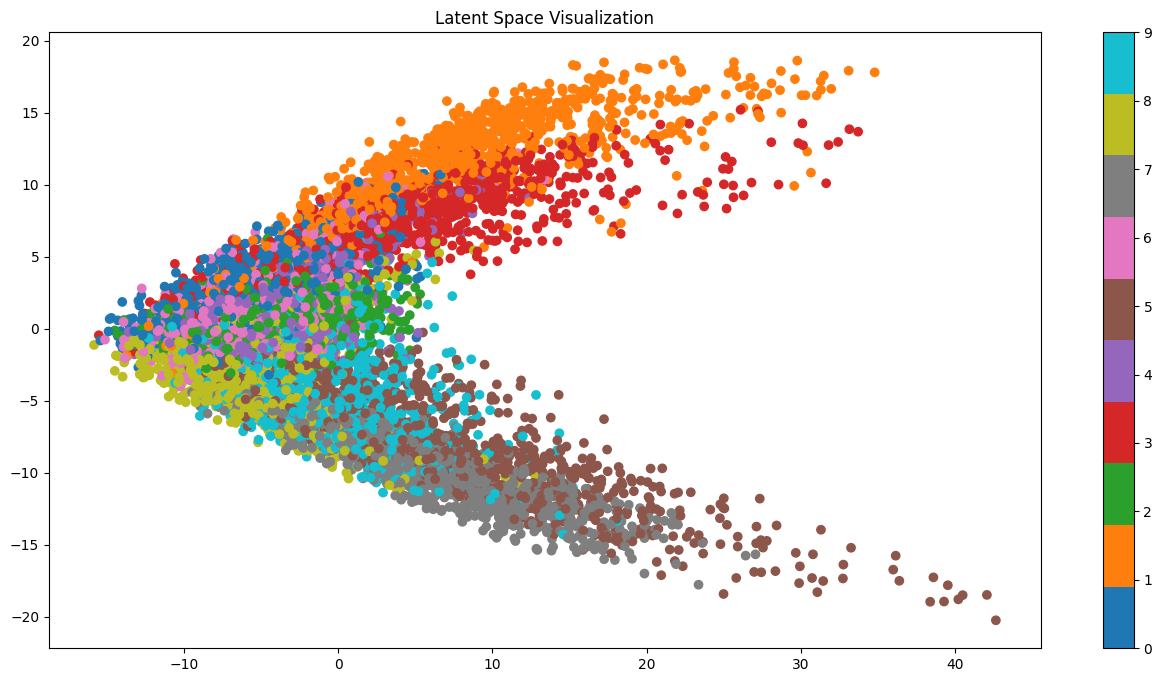

In [30]:
plt.figure(figsize=(16,8))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=y_test,
    cmap='tab10'
)

plt.colorbar(scatter)
plt.title('Latent Space Visualization')
plt.show()

In [32]:
mse = np.mean(
    np.square(X_test - reconstructed),
    axis=(1,2)
)

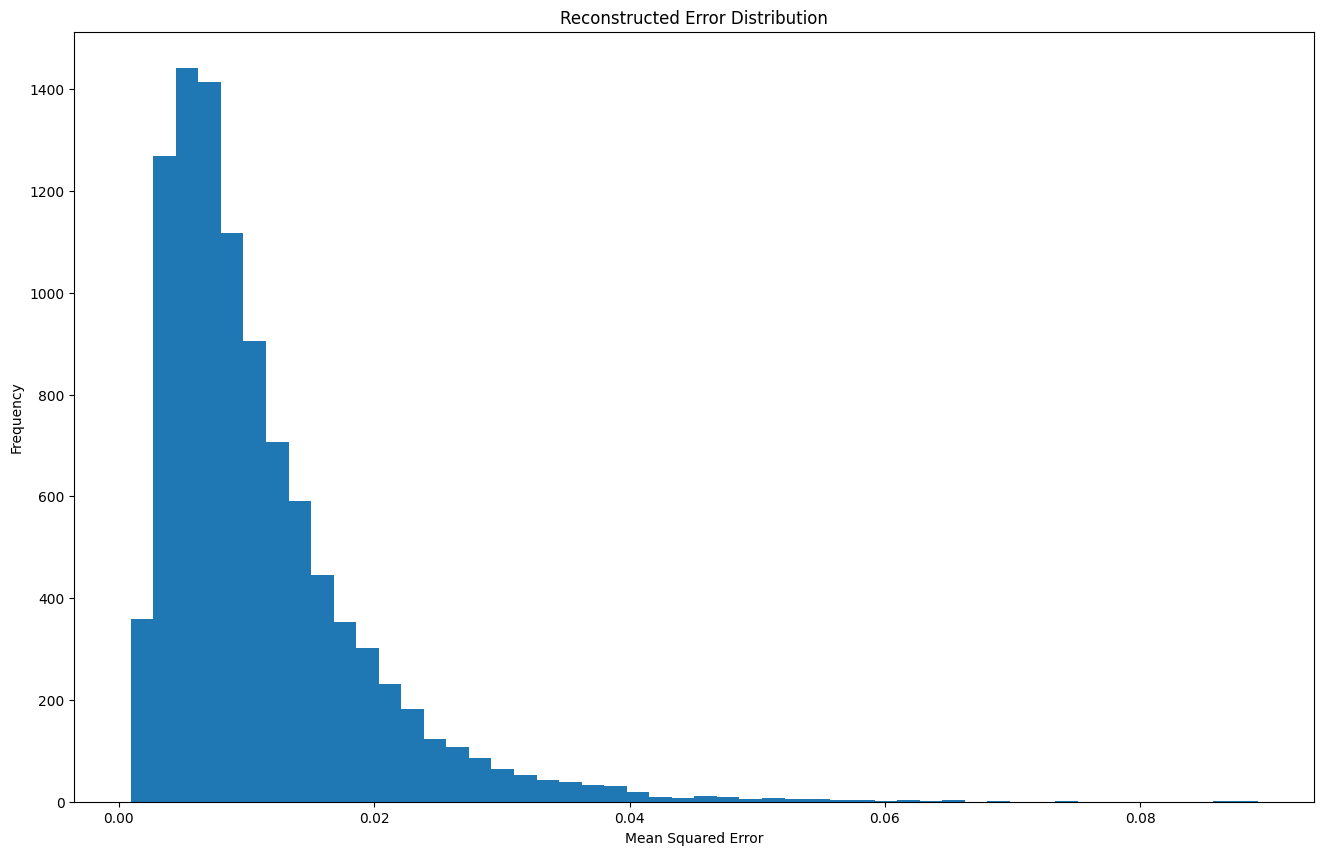

In [34]:
plt.figure(figsize=(16,10))
plt.hist(mse,bins=50)

plt.title('Reconstructed Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.show()

In [35]:
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

In [36]:
X_train_noisy_flat = X_train_noisy.reshape(-1,784)
X_test_noisy_flat = X_test_noisy.reshape(-1,784)

In [37]:
history_noise = autoencoder.fit(
    X_train_noisy_flat,
    X_train_flat,
    epochs=15,
    batch_size=256,
    validation_data=(X_test_noisy_flat, X_test_flat)
)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.0183 - loss: 0.3103 - val_accuracy: 0.0166 - val_loss: 0.3011
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.0225 - loss: 0.2970 - val_accuracy: 0.0217 - val_loss: 0.2986
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0220 - loss: 0.2944 - val_accuracy: 0.0198 - val_loss: 0.2979
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0237 - loss: 0.2930 - val_accuracy: 0.0217 - val_loss: 0.2963
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.0235 - loss: 0.2921 - val_accuracy: 0.0202 - val_loss: 0.2962
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0237 - loss: 0.2914 - val_accuracy: 0.0226 - val_loss: 0.2955
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.0238 - loss: 0.2909 - val_accuracy: 0.0197 - val_loss: 0.2953
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.0237 - loss: 0.2904 - val_ac

In [38]:
denoised = autoencoder.predict(X_test_noisy_flat)

denoised = denoised.reshape(-1,28,28)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


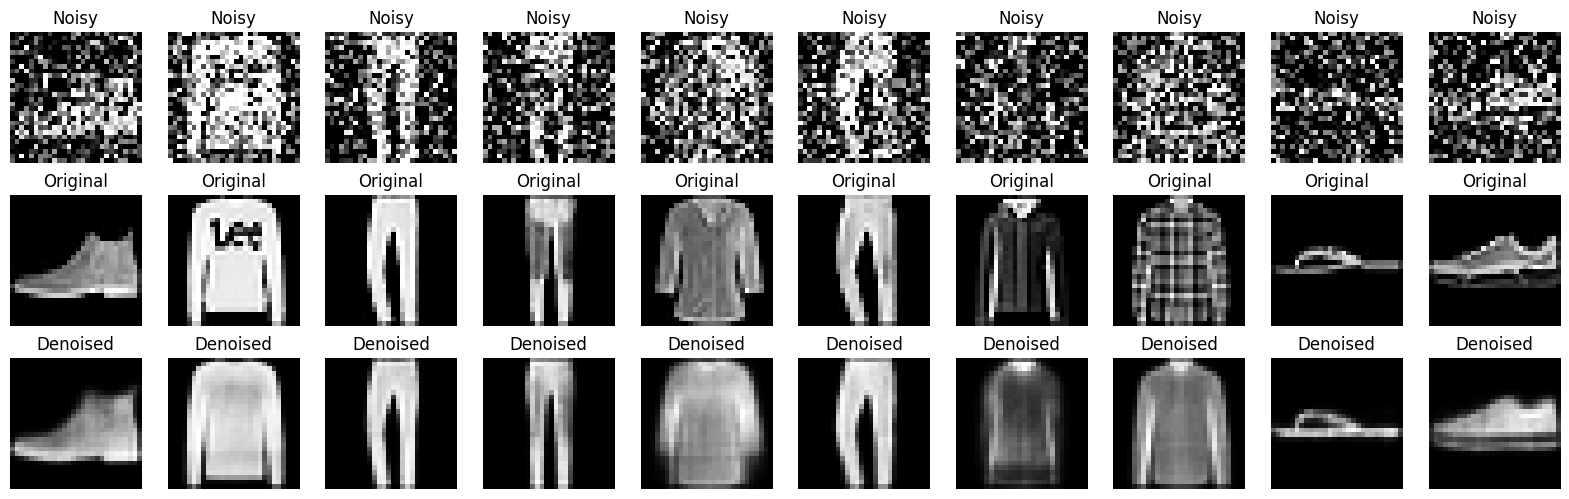

In [39]:
plt.figure(figsize=(20,6))

for i in range(10):

    # Noisy
    ax = plt.subplot(3,10,i+1)
    plt.imshow(X_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Original
    ax = plt.subplot(3,10,i+11)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,10,i+21)
    plt.imshow(denoised[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()